In [2]:
import sys
sys.path.append("..")

from src.data import fetch_prices, compute_returns, compute_rolling_volatility
from src.regime import build_hmm_features, fit_hmm, label_regimes, plot_regimes
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
nifty = fetch_prices(tickers="^NSEI", start="2015-01-01")
nifty_returns = compute_returns(nifty)

[*********************100%***********************]  1 of 1 completed

Requested start: 2015-01-01
  ^NSEI: first valid 2015-01-02


In [4]:
prices = fetch_prices()
returns = compute_returns(prices)
print("Price shape:", prices.shape)
print("Returns shape:", returns.shape)

[*********************100%***********************]  10 of 10 completed

Requested start: 2006-01-01
  BAJFINANCE.NS: first valid 2006-01-02
  HDFCBANK.NS: first valid 2006-01-02
  ICICIBANK.NS: first valid 2006-01-02
  INFY.NS: first valid 2006-01-02
  ITC.NS: first valid 2006-01-02
  MARUTI.NS: first valid 2006-01-02
  RELIANCE.NS: first valid 2006-01-02
  SUNPHARMA.NS: first valid 2006-01-02
  TCS.NS: first valid 2006-01-02
  WIPRO.NS: first valid 2006-01-02
Price shape: (5069, 10)
Returns shape: (5068, 10)


In [5]:
ew_return = returns.mean(axis=1)
ew_price = (1 + ew_return).cumprod()  

In [6]:
features = build_hmm_features(ew_return)
model, hidden_states = fit_hmm(features, n_states=4)

In [7]:
regime_series, label_map = label_regimes(model, hidden_states, features)
print("\nRegime distribution:")
print(regime_series.value_counts())

State stats (return, vol): {0: {'return': np.float64(0.0008755020089720081), 'vol': np.float64(0.09879332563840543)}, 1: {'return': np.float64(0.000747070389210749), 'vol': np.float64(0.19781277655974963)}, 2: {'return': np.float64(0.0004516137266598783), 'vol': np.float64(0.3690839596752898)}, 3: {'return': np.float64(0.0003033826802541387), 'vol': np.float64(0.13974731094769866)}}
Labels: {0: 'Bull', 3: 'Neutral', 1: 'High-Vol', 2: 'Bear/Crisis'}

Regime distribution:
regime
Neutral        1737
Bull           1537
High-Vol       1105
Bear/Crisis     669
Name: count, dtype: int64


In [8]:
print("\nSample regimes around COVID crash:")
print(regime_series["2020-01":"2020-06"])


Sample regimes around COVID crash:
Date
2020-01-01        Bull
2020-01-02        Bull
2020-01-03        Bull
2020-01-06        Bull
2020-01-07        Bull
                ...   
2020-06-24    High-Vol
2020-06-25    High-Vol
2020-06-26    High-Vol
2020-06-29    High-Vol
2020-06-30    High-Vol
Name: regime, Length: 122, dtype: str


In [9]:
print("ew_price:", ew_price.shape, ew_price.index.min(), ew_price.index.max())
print("regime_series:", regime_series.shape, regime_series.index.min(), regime_series.index.max())
print(ew_price.head())
print(regime_series.head())

ew_price: (5068,) 2006-01-03 00:00:00 2026-07-17 00:00:00
regime_series: (5048,) 2006-02-02 00:00:00 2026-07-17 00:00:00
Date
2006-01-03    1.014246
2006-01-04    1.024962
2006-01-05    1.019913
2006-01-06    1.021184
2006-01-09    1.011546
dtype: float64
Date
2006-02-02    Neutral
2006-02-03    Neutral
2006-02-06    Neutral
2006-02-07    Neutral
2006-02-08    Neutral
Name: regime, dtype: str


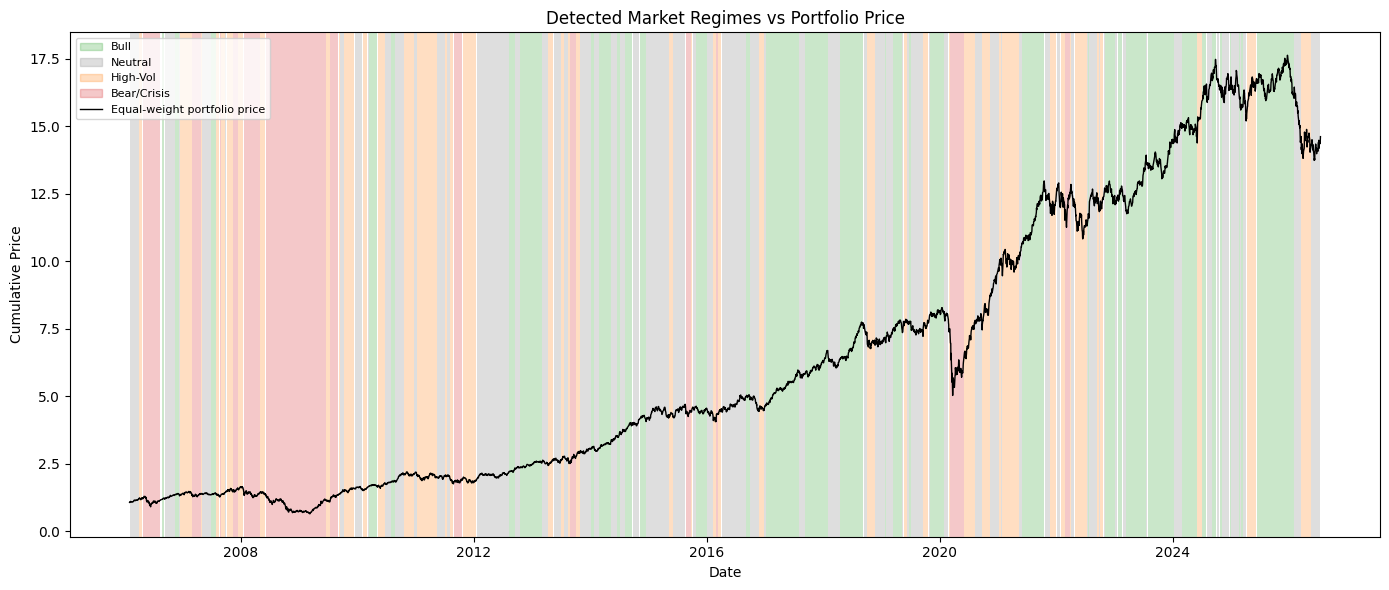

Plot saved to D:\quantrisk\data\regime_plot.png


In [10]:
plot_regimes(ew_price, regime_series)

In [11]:
from src.data import fetch_prices

prices = fetch_prices()
print(prices.shape)
print(prices.columns)

[*********************100%***********************]  10 of 10 completed

Requested start: 2006-01-01
  BAJFINANCE.NS: first valid 2006-01-02
  HDFCBANK.NS: first valid 2006-01-02
  ICICIBANK.NS: first valid 2006-01-02
  INFY.NS: first valid 2006-01-02
  ITC.NS: first valid 2006-01-02
  MARUTI.NS: first valid 2006-01-02
  RELIANCE.NS: first valid 2006-01-02
  SUNPHARMA.NS: first valid 2006-01-02
  TCS.NS: first valid 2006-01-02
  WIPRO.NS: first valid 2006-01-02
(5069, 10)
Index(['BAJFINANCE.NS', 'HDFCBANK.NS', 'ICICIBANK.NS', 'INFY.NS', 'ITC.NS',
       'MARUTI.NS', 'RELIANCE.NS', 'SUNPHARMA.NS', 'TCS.NS', 'WIPRO.NS'],
      dtype='str', name='Ticker')


In [12]:
print(regime_series["2020-03"])

Date
2020-03-02       High-Vol
2020-03-03       High-Vol
2020-03-04       High-Vol
2020-03-05       High-Vol
2020-03-06       High-Vol
2020-03-09    Bear/Crisis
2020-03-11    Bear/Crisis
2020-03-12    Bear/Crisis
2020-03-13    Bear/Crisis
2020-03-16    Bear/Crisis
2020-03-17    Bear/Crisis
2020-03-18    Bear/Crisis
2020-03-19    Bear/Crisis
2020-03-20    Bear/Crisis
2020-03-23    Bear/Crisis
2020-03-24    Bear/Crisis
2020-03-25    Bear/Crisis
2020-03-26    Bear/Crisis
2020-03-27    Bear/Crisis
2020-03-30    Bear/Crisis
2020-03-31    Bear/Crisis
Name: regime, dtype: str


In [13]:
regime_series.groupby(regime_series.dt.year if hasattr(regime_series, 'dt') else regime_series.index.year).value_counts(normalize=True)

Date  regime     
2006  Neutral        0.398230
      Bear/Crisis    0.349558
      Bull           0.128319
      High-Vol       0.123894
2007  High-Vol       0.459677
                       ...   
2025  Neutral        0.220884
      High-Vol       0.156627
2026  Neutral        0.544118
      High-Vol       0.294118
      Bull           0.161765
Name: proportion, Length: 66, dtype: float64

In [14]:
print(regime_series.value_counts(normalize=True))

regime
Neutral        0.344097
Bull           0.304477
High-Vol       0.218899
Bear/Crisis    0.132528
Name: proportion, dtype: float64


In [15]:
from src.risk import sharpe_ratio, max_drawdown, sortino_ratio

print("Sharpe:", sharpe_ratio(ew_return))
dd = max_drawdown(ew_price)
print("Max Drawdown:", dd["max_drawdown"])
print("Peak:", dd["peak_date"], "-> Trough:", dd["trough_date"])
print("Sortino:", sortino_ratio(ew_return))

Sharpe: 0.7746117849881048
Max Drawdown: -0.6060930973215656
Peak: 2008-01-02 00:00:00 -> Trough: 2009-03-09 00:00:00
Sortino: 1.003665689559716


In [16]:
from src.risk import fit_garch, forecast_volatility

garch_fit = fit_garch(ew_return)
vol_forecast = forecast_volatility(garch_fit, horizon=5)
print("Next 5-day volatility forecast (decimal):", vol_forecast)

GARCH(1,1) fitted — omega=0.0194, alpha=0.0823, beta=0.9031, persistence (alpha+beta)=0.9854
Next 5-day volatility forecast (decimal): [0.00896555 0.00900826 0.00905015 0.00909124 0.00913156]


In [17]:
from src.risk import historical_cvar, parametric_cvar

hist_cvar = historical_cvar(ew_return, confidence_level=0.95)
print("Historical 95% CVaR (daily):", hist_cvar)

garch_vol = forecast_volatility(garch_fit, horizon=1)[0]
param_cvar = parametric_cvar(mean_return=ew_return.mean(), volatility=garch_vol,
                               confidence_level=0.95, dist="t", nu=5)
print("Parametric (GARCH-based) 95% CVaR (daily):", param_cvar)

Historical 95% CVaR (daily): -0.02938261497380612
Parametric (GARCH-based) 95% CVaR (daily): -0.025304694528353492


In [18]:
from src.risk import get_fitted_nu

fitted_nu = get_fitted_nu(garch_fit)
print("Fitted nu:", fitted_nu)

param_cvar_v2 = parametric_cvar(mean_return=ew_return.mean(), volatility=garch_vol,
                                  confidence_level=0.95, dist="t", nu=fitted_nu)
print("Parametric CVaR (fitted nu):", param_cvar_v2)

Fitted nu: 8.23730976253026
Parametric CVaR (fitted nu): -0.021790056312925406


In [19]:
from src.risk import calculate_beta
beta = calculate_beta(ew_return, nifty_returns.iloc[:, 0] if hasattr(nifty_returns, 'columns') else nifty_returns)
print("Portfolio beta vs Nifty 50:", beta)

Portfolio beta vs Nifty 50: 0.9380246345187337


In [20]:
from src.portfolio import compare_regime_portfolios

results, summary, shrinkage_intensities = compare_regime_portfolios(returns, regime_series)
print(summary)
print("\nShrinkage intensities:", shrinkage_intensities)
print("\nBull weights:\n", results["Bull"]["weights"])
print("\nBear/Crisis weights (shrunk):\n", results["Bear/Crisis"]["weights"])

'Neutral': 1737 obs, shrinkage intensity=0.019
'High-Vol': 1105 obs, shrinkage intensity=0.017
'Bear/Crisis': 669 obs, shrinkage intensity=0.019
'Bull': 1537 obs, shrinkage intensity=0.042
                      min_achievable_annual_vol
Neutral                                0.138633
High-Vol                               0.182112
Bear/Crisis                            0.334301
Bull                                   0.095602
Static (full sample)                   0.183327

Shrinkage intensities: {'Neutral': np.float64(0.018605177539900083), 'High-Vol': np.float64(0.01683110839517773), 'Bear/Crisis': np.float64(0.01871540427778495), 'Bull': np.float64(0.04206426767964126)}

Bull weights:
 Ticker
BAJFINANCE.NS    0.046240
HDFCBANK.NS      0.199229
ICICIBANK.NS     0.050074
INFY.NS          0.074700
ITC.NS           0.137830
MARUTI.NS        0.136142
RELIANCE.NS      0.079612
SUNPHARMA.NS     0.094502
TCS.NS           0.123534
WIPRO.NS         0.058138
dtype: float64

Bear/Crisis weights 

In [21]:
from src.stress_test import run_stress_test

stress_summary = run_stress_test(returns, regime_series, results)
stress_summary


--- GFC (2008-09) (2008-01-01 to 2009-03-31) ---
  Static:              return=-34.90%  vol=32.84%  max_dd=-44.88%
  Regime-Conditional:  return=-27.21%  vol=30.46%  max_dd=-39.30%  switches=3

--- COVID Crash (2020) (2020-02-01 to 2020-04-30) ---
  Static:              return=-16.35%  vol=52.04%  max_dd=-33.17%
  Regime-Conditional:  return=-12.21%  vol=51.71%  max_dd=-31.89%  switches=2

--- 2022 Rate Shock (2022-01-01 to 2022-12-31) ---
  Static:              return=10.16%  vol=16.17%  max_dd=-13.06%
  Regime-Conditional:  return=9.54%  vol=16.06%  max_dd=-13.49%  switches=14


total_return  annualized_vol  \
window             strategy                                           
GFC (2008-09)      Static                 -0.348952        0.328379   
                   Regime-Conditional     -0.272054        0.304571   
COVID Crash (2020) Static                 -0.163466        0.520423   
                   Regime-Conditional     -0.122112        0.517065   
2022 Rate Shock    Static                  0.101647        0.161712   
                   Regime-Conditional      0.095405        0.160564   

                                       max_drawdown  regime_switches  
window             strategy                                           
GFC (2008-09)      Static                 -0.448752              NaN  
                   Regime-Conditional     -0.392983              3.0  
COVID Crash (2020) Static                 -0.331729              NaN  
                   Regime-Conditional     -0.318911              2.0  
2022 Rate Shock    Static                 -0.130649              NaN  
                   Regime-Conditional     -0.134910             14.0

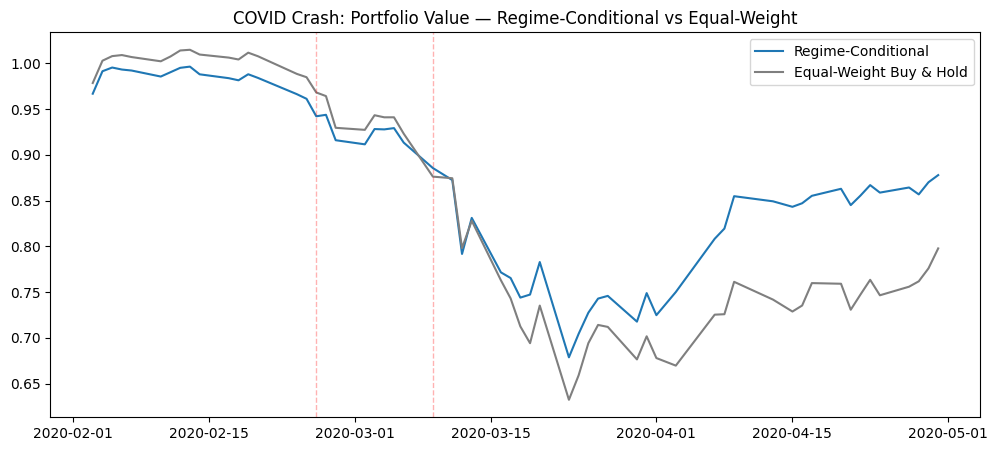

Final values — Regime-Conditional: 0.8779, Equal-Weight: 0.7978


In [22]:
from src.stress_test import regime_switching_backtest
import matplotlib.pyplot as plt

covid = regime_switching_backtest(returns, regime_series, results,
                                   start="2020-02-01", end="2020-04-30")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(covid["regime_conditional_value"], label="Regime-Conditional", color="#1f77b4")
ax.plot(covid["equal_weight_value"], label="Equal-Weight Buy & Hold", color="#7f7f7f")
for d in covid["switch_dates"]:
    ax.axvline(d, color="red", alpha=0.3, linestyle="--", linewidth=1)
ax.set_title("COVID Crash: Portfolio Value — Regime-Conditional vs Equal-Weight")
ax.legend()
plt.show()

print(f"Final values — Regime-Conditional: {covid['regime_conditional_value'].iloc[-1]:.4f}, "
      f"Equal-Weight: {covid['equal_weight_value'].iloc[-1]:.4f}")

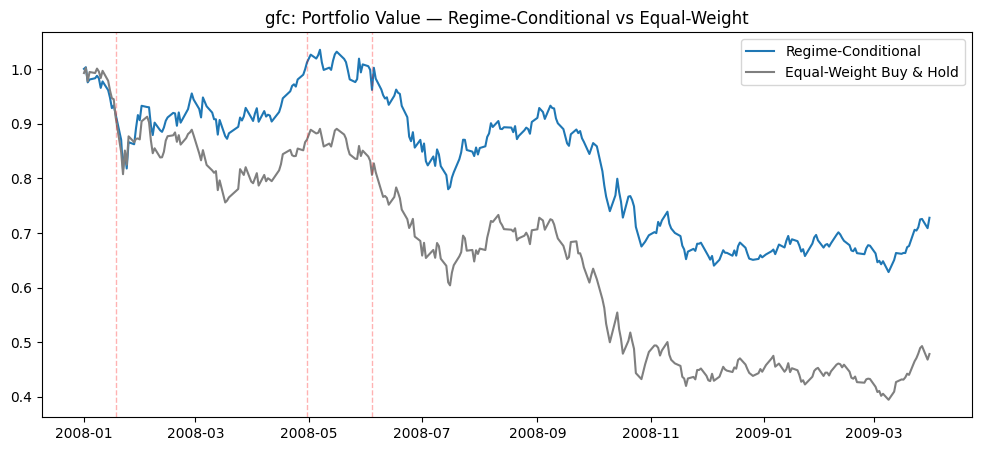

Final values — Regime-Conditional: 0.7279, Equal-Weight: 0.4786


In [23]:
gfc = regime_switching_backtest(returns, regime_series, results,
                                 start="2008-01-01", end="2009-03-31")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(gfc["regime_conditional_value"], label="Regime-Conditional", color="#1f77b4")
ax.plot(gfc["equal_weight_value"], label="Equal-Weight Buy & Hold", color="#7f7f7f")
for d in gfc["switch_dates"]:
    ax.axvline(d, color="red", alpha=0.3, linestyle="--", linewidth=1)
ax.set_title("gfc: Portfolio Value — Regime-Conditional vs Equal-Weight")
ax.legend()
plt.show()

print(f"Final values — Regime-Conditional: {gfc['regime_conditional_value'].iloc[-1]:.4f}, "
      f"Equal-Weight: {gfc['equal_weight_value'].iloc[-1]:.4f}")

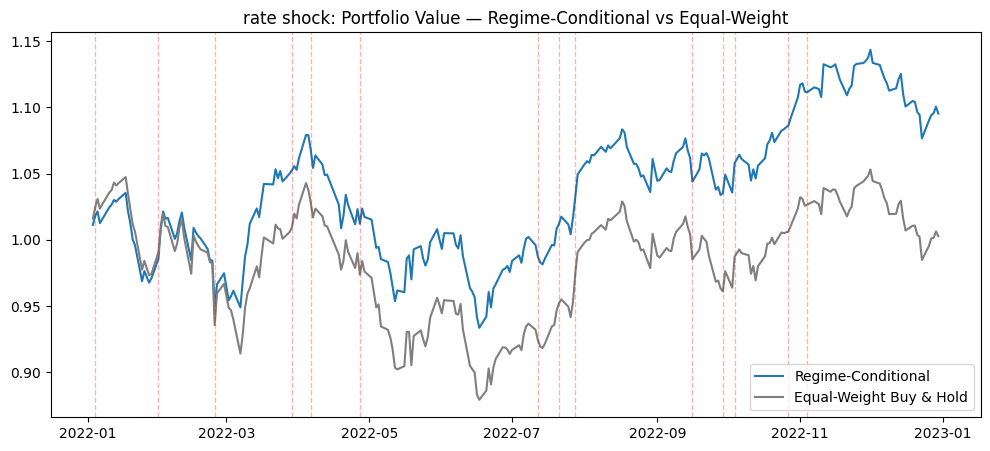

Final values — Regime-Conditional: 1.0954, Equal-Weight: 1.0028


In [24]:
rate_shock = regime_switching_backtest(returns, regime_series, results,
                                        start="2022-01-01", end="2022-12-31")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(rate_shock["regime_conditional_value"], label="Regime-Conditional", color="#1f77b4")
ax.plot(rate_shock["equal_weight_value"], label="Equal-Weight Buy & Hold", color="#7f7f7f")
for d in rate_shock["switch_dates"]:
    ax.axvline(d, color="red", alpha=0.3, linestyle="--", linewidth=1)
ax.set_title("rate shock: Portfolio Value — Regime-Conditional vs Equal-Weight")
ax.legend()
plt.show()

print(f"Final values — Regime-Conditional: {rate_shock['regime_conditional_value'].iloc[-1]:.4f}, "
      f"Equal-Weight: {rate_shock['equal_weight_value'].iloc[-1]:.4f}")